In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Load your dataset
df = pd.read_csv("va_scc_lp_address.csv")

# Preview
df.head()

,Unnamed: 0,street-1,street-2,city,state,zip
0,Suite 300,11350 Random Hills Road,Fairfax,VA,22030,NaN
1,3625 CORNELL ROAD,NaN,FAIRFAX,VA,22030,NaN
2,3625 CORNELL ROAD,NaN,FAIRFAX,VA,22030,NaN
3,1330 Mercer Lane,NaN,McLean,VA,22101,NaN
4,Suite 225,333 South Glebe Road,Arlington,VA,22204,NaN


In [3]:
df.info()
df.describe(include='all')

# Check missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 11057 entries, 0 to 11056
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  11057 non-null  str    
 1   street-1    2203 non-null   str    
 2   street-2    11057 non-null  str    
 3   city        11057 non-null  str    
 4   state       11057 non-null  str    
 5   zip         0 non-null      float64
dtypes: float64(1), str(5)
memory usage: 956.3 KB


Unnamed: 0        0
street-1       8854
street-2          0
city              0
state             0
zip           11057
dtype: int64

In [4]:
# Drop duplicates
df = df.drop_duplicates()

# Fill missing values (simple approach)
df = df.fillna("Unknown")

In [6]:
if target_column in df.columns:
    X = df.drop(columns=[target_column])
    y = df[target_column]
else:
    print("Column not found:", target_column)

Column not found: CITY


In [7]:
for col in df.columns:
    print(f"'{col}'")

'Unnamed: 0'
'street-1'
'street-2'
'city'
'state'
'zip'


In [14]:
df.head()
df.columns

Index(['Unnamed: 0', 'street-1', 'street-2', 'city', 'state', 'zip'], dtype='str')

In [17]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

data = load_iris()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Success!")

Success!


In [18]:
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)

# Predictions
dt_preds = dt_model.predict(X_test)

# Evaluation
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_preds))
print(classification_report(y_test, dt_preds))

Decision Tree Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [19]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predictions
rf_preds = rf_model.predict(X_test)

# Evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))
print(classification_report(y_test, rf_preds))

Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



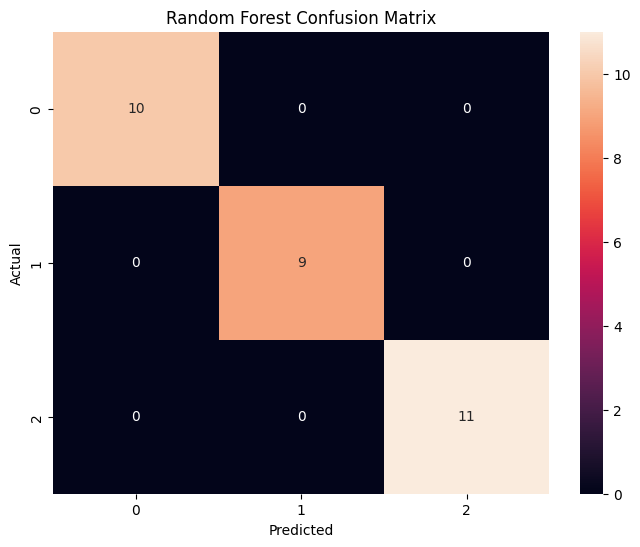

In [20]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, rf_preds), annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

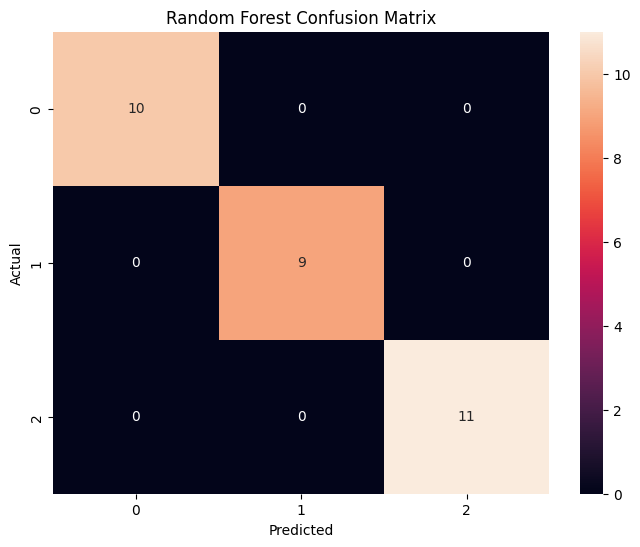

In [21]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, rf_preds), annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()